In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
dataset = pd.read_csv(r"C:\Ddrive\Bits\sem1\ML\Assignment2\diabetes_012_health_indicators_BRFSS2015.csv")

In [3]:
dataset.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [4]:
# Check for NaN or null values in each column
missing_values = dataset.isnull().sum()

# Filter columns with missing values
missing_columns = missing_values[missing_values > 0]

# Display columns with missing values and their counts
print(missing_columns)

Series([], dtype: int64)


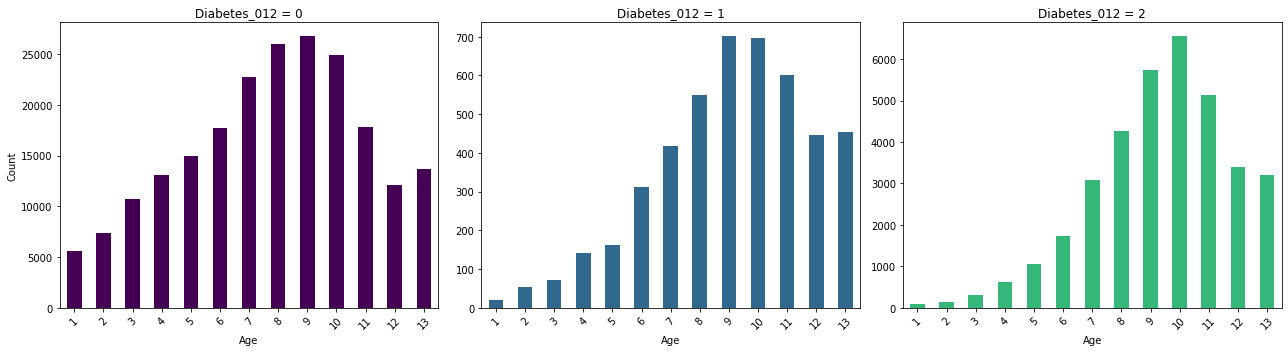

In [5]:
age_diabetes_counts = dataset.groupby(['Age', 'Diabetes_012']).size().unstack(fill_value=0)
# Create separate bar plots for each Diabetes_012 category with best scaling for each plot
categories = age_diabetes_counts.columns
fig, axes = plt.subplots(1, len(categories), figsize=(18, 5), sharey=False)

for idx, cat in enumerate(categories):
    ax = axes[idx]
    data = age_diabetes_counts[cat]
    # Use log scale if the range is large, else linear
    if data.max() / max(data.min(), 1) > 100:
        data.plot(kind='bar', ax=ax, color=plt.cm.viridis(idx / len(categories)), logy=True)
        ax.set_ylabel('Count (log scale)' if idx == 0 else "")
    else:
        data.plot(kind='bar', ax=ax, color=plt.cm.viridis(idx / len(categories)))
        ax.set_ylabel('Count' if idx == 0 else "")
    ax.set_title(f'Diabetes_012 = {int(cat)}')
    ax.set_xlabel('Age')
    ax.set_xticklabels(age_diabetes_counts.index.astype(int), rotation=45)

plt.tight_layout()
plt.show()


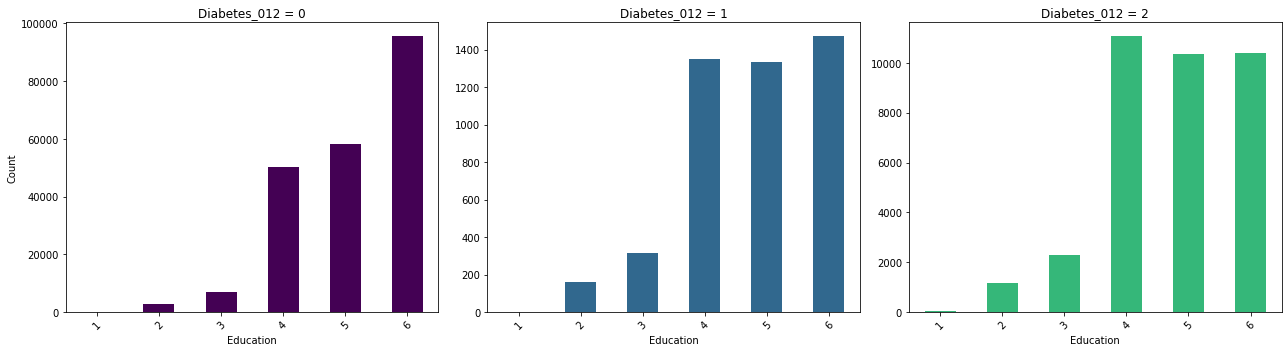

In [6]:
# Create separate bar plots for each Diabetes_012 category with best scaling for each plot using Education instead of Age
education_diabetes_counts = dataset.groupby(['Education', 'Diabetes_012']).size().unstack(fill_value=0)
categories = education_diabetes_counts.columns
fig, axes = plt.subplots(1, len(categories), figsize=(18, 5), sharey=False)

for idx, cat in enumerate(categories):
    ax = axes[idx]
    data = education_diabetes_counts[cat]
    # Use log scale if the range is large, else linear
    if data.max() / max(data.min(), 1) > 1000: #ignoring log
        data.plot(kind='bar', ax=ax, color=plt.cm.viridis(idx / len(categories)), logy=True)
        ax.set_ylabel('Count (log scale)' if idx == 0 else "")
    else:
        data.plot(kind='bar', ax=ax, color=plt.cm.viridis(idx / len(categories)))
        ax.set_ylabel('Count' if idx == 0 else "")
    ax.set_title(f'Diabetes_012 = {int(cat)}')
    ax.set_xlabel('Education')
    ax.set_xticklabels(education_diabetes_counts.index.astype(int), rotation=45)

plt.tight_layout()
plt.show()

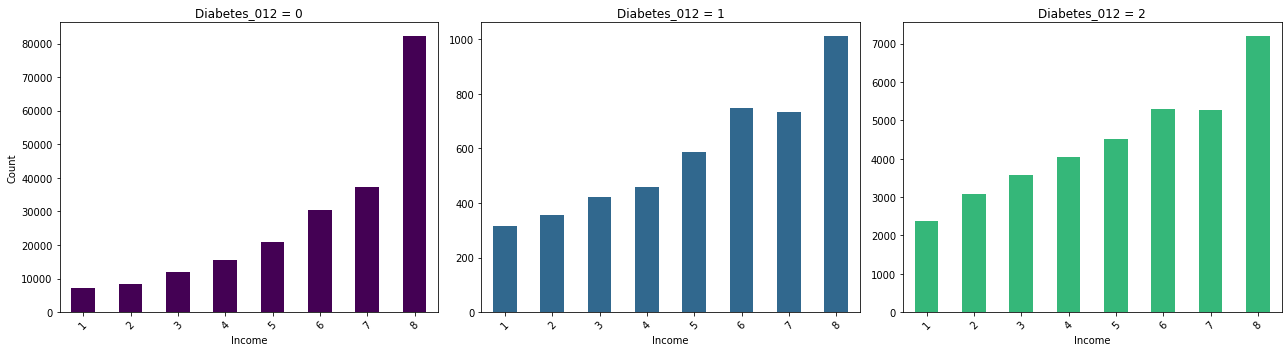

In [7]:
# Create separate bar plots for each Diabetes_012 category with best scaling for each plot using Education instead of Age
Income_diabetes_counts = dataset.groupby(['Income', 'Diabetes_012']).size().unstack(fill_value=0)
categories = Income_diabetes_counts.columns
fig, axes = plt.subplots(1, len(categories), figsize=(18, 5), sharey=False)

for idx, cat in enumerate(categories):
    ax = axes[idx]
    data = Income_diabetes_counts[cat]
    # Use log scale if the range is large, else linear
    if data.max() / max(data.min(), 1) > 100:
        data.plot(kind='bar', ax=ax, color=plt.cm.viridis(idx / len(categories)), logy=True)
        ax.set_ylabel('Count (log scale)' if idx == 0 else "")
    else:
        data.plot(kind='bar', ax=ax, color=plt.cm.viridis(idx / len(categories)))
        ax.set_ylabel('Count' if idx == 0 else "")
    ax.set_title(f'Diabetes_012 = {int(cat)}')
    ax.set_xlabel('Income')
    ax.set_xticklabels(Income_diabetes_counts.index.astype(int), rotation=45)

plt.tight_layout()
plt.show()

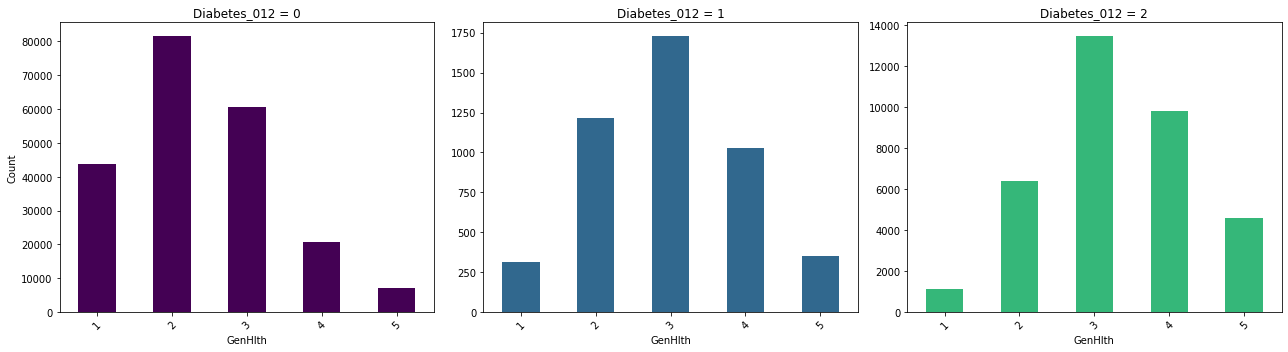

In [8]:
# Create separate bar plots for each Diabetes_012 category with best scaling for each plot using Education instead of Age
GenHlth_diabetes_counts = dataset.groupby(['GenHlth', 'Diabetes_012']).size().unstack(fill_value=0)
categories = GenHlth_diabetes_counts.columns
fig, axes = plt.subplots(1, len(categories), figsize=(18, 5), sharey=False)

for idx, cat in enumerate(categories):
    ax = axes[idx]
    data = GenHlth_diabetes_counts[cat]
    # Use log scale if the range is large, else linear
    if data.max() / max(data.min(), 1) > 100:
        data.plot(kind='bar', ax=ax, color=plt.cm.viridis(idx / len(categories)), logy=True)
        ax.set_ylabel('Count (log scale)' if idx == 0 else "")
    else:
        data.plot(kind='bar', ax=ax, color=plt.cm.viridis(idx / len(categories)))
        ax.set_ylabel('Count' if idx == 0 else "")
    ax.set_title(f'Diabetes_012 = {int(cat)}')
    ax.set_xlabel('GenHlth')
    ax.set_xticklabels(GenHlth_diabetes_counts.index.astype(int), rotation=45)

plt.tight_layout()
plt.show()

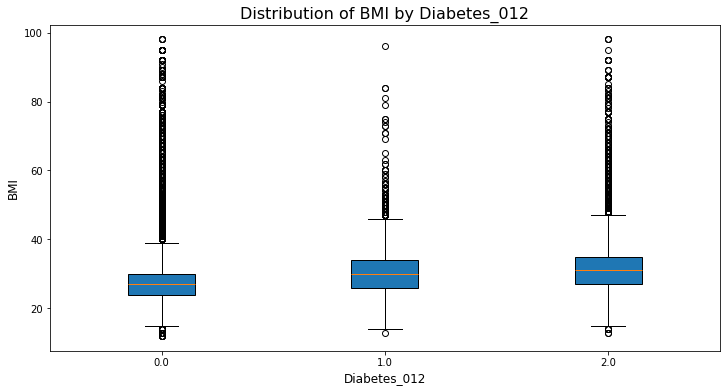

In [9]:
plt.figure(figsize=(12, 6))

# Prepare data for each Diabetes_012 category
data = [dataset[dataset['Diabetes_012'] == cat]['BMI'] for cat in sorted(dataset['Diabetes_012'].unique())]

# Create a box plot using matplotlib
plt.boxplot(data, positions=sorted(dataset['Diabetes_012'].unique()), patch_artist=True)

plt.title('Distribution of BMI by Diabetes_012', fontsize=16)
plt.xlabel('Diabetes_012', fontsize=12)
plt.ylabel('BMI', fontsize=12)
plt.xticks(sorted(dataset['Diabetes_012'].unique()))

plt.show()

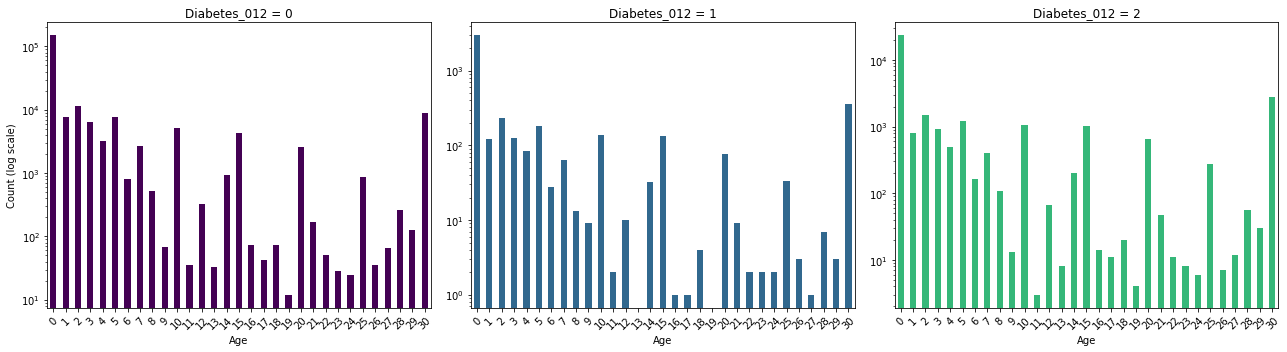

In [ ]:
MentHlth_diabetes_counts = dataset.groupby(['MentHlth', 'Diabetes_012']).size().unstack(fill_value=0)
# Create separate bar plots for each Diabetes_012 category with best scaling for each plot
categories = MentHlth_diabetes_counts.columns
fig, axes = plt.subplots(1, len(categories), figsize=(18, 5), sharey=False)

for idx, cat in enumerate(categories):
    ax = axes[idx]
    data = MentHlth_diabetes_counts[cat]
    # Use log scale if the range is large, else linear
    if data.max() / max(data.min(), 1) > 100:
        data.plot(kind='bar', ax=ax, color=plt.cm.viridis(idx / len(categories)), logy=True)
        ax.set_ylabel('Count (log scale)' if idx == 0 else "")
    else:
        data.plot(kind='bar', ax=ax, color=plt.cm.viridis(idx / len(categories)))
        ax.set_ylabel('Count' if idx == 0 else "")
    ax.set_title(f'Diabetes_012 = {int(cat)}')
    ax.set_xlabel('Age')
    ax.set_xticklabels(MentHlth_diabetes_counts.index.astype(int), rotation=45)

plt.tight_layout()
plt.show()

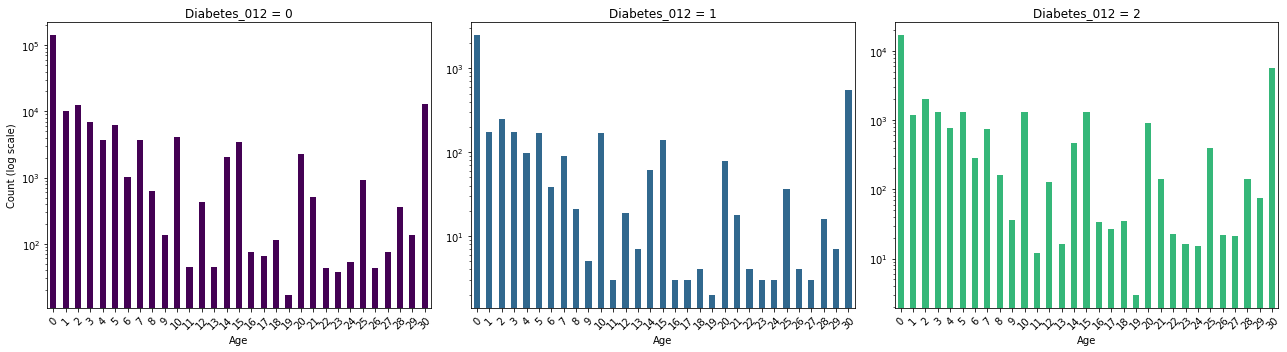

In [12]:
PhysHlth_diabetes_counts = dataset.groupby(['PhysHlth', 'Diabetes_012']).size().unstack(fill_value=0)
# Create separate bar plots for each Diabetes_012 category with best scaling for each plot
categories = PhysHlth_diabetes_counts.columns
fig, axes = plt.subplots(1, len(categories), figsize=(18, 5), sharey=False)

for idx, cat in enumerate(categories):
    ax = axes[idx]
    data = PhysHlth_diabetes_counts[cat]
    # Use log scale if the range is large, else linear
    if data.max() / max(data.min(), 1) > 100:
        data.plot(kind='bar', ax=ax, color=plt.cm.viridis(idx / len(categories)), logy=True)
        ax.set_ylabel('Count (log scale)' if idx == 0 else "")
    else:
        data.plot(kind='bar', ax=ax, color=plt.cm.viridis(idx / len(categories)))
        ax.set_ylabel('Count' if idx == 0 else "")
    ax.set_title(f'Diabetes_012 = {int(cat)}')
    ax.set_xlabel('Age')
    ax.set_xticklabels(PhysHlth_diabetes_counts.index.astype(int), rotation=45)

plt.tight_layout()
plt.show()

In [18]:
Binary_cols = [col for col in dataset.columns if set(dataset[col].dropna().unique()).issubset({0.0, 1.0})]
print(Binary_cols)
print(len(Binary_cols))
non_binary_cols = [col for col in dataset.columns if col not in Binary_cols]
print(non_binary_cols)
print(len(non_binary_cols))

['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']
14
['Diabetes_012', 'BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']
8


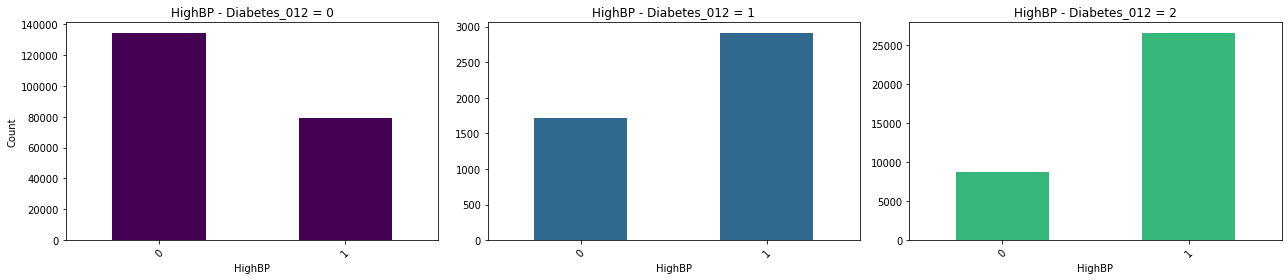

Total count for 'HighBP': 253680
Value counts for 'HighBP':
0.0    144851
1.0    108829
Name: HighBP, dtype: int64



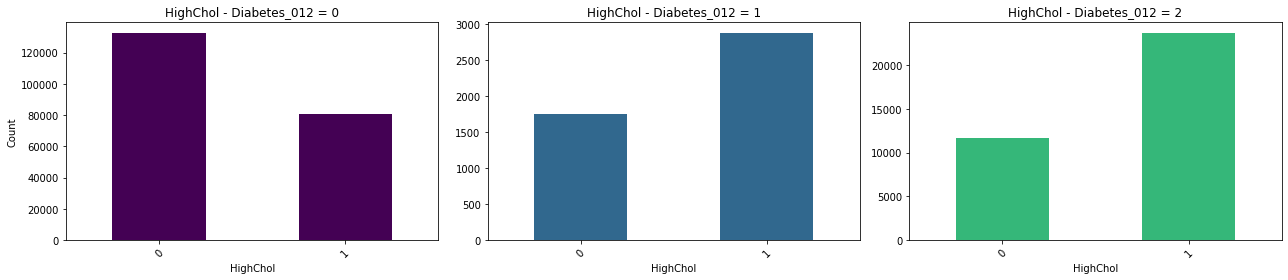

Total count for 'HighChol': 253680
Value counts for 'HighChol':
0.0    146089
1.0    107591
Name: HighChol, dtype: int64



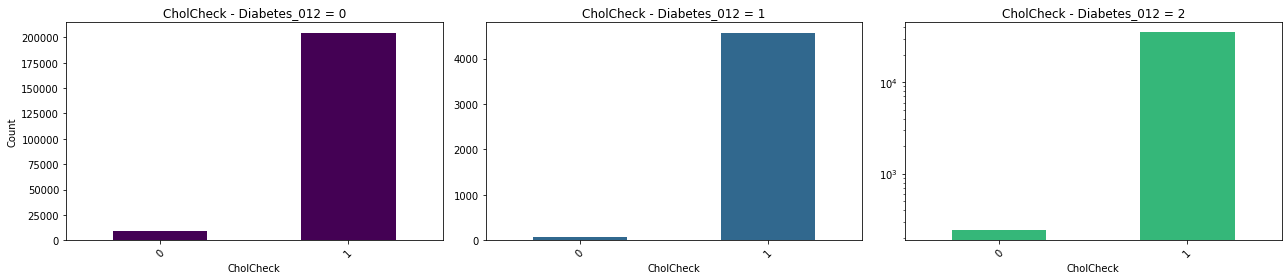

Total count for 'CholCheck': 253680
Value counts for 'CholCheck':
1.0    244210
0.0      9470
Name: CholCheck, dtype: int64



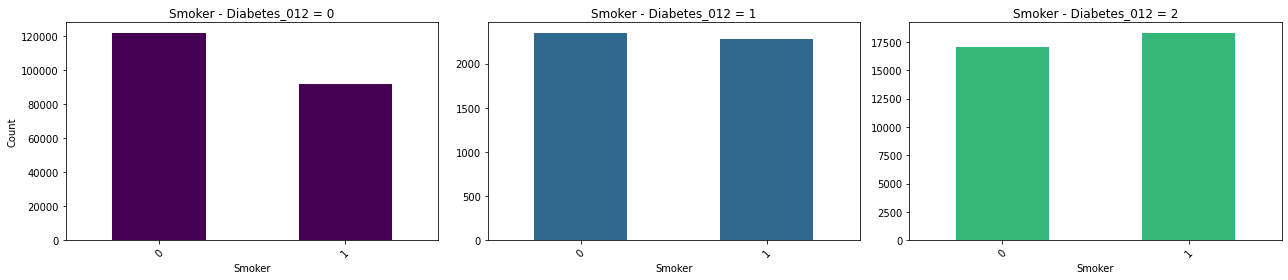

Total count for 'Smoker': 253680
Value counts for 'Smoker':
0.0    141257
1.0    112423
Name: Smoker, dtype: int64



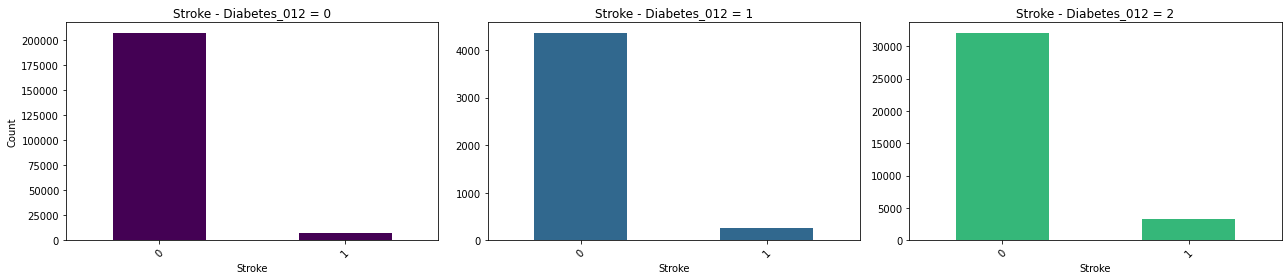

Total count for 'Stroke': 253680
Value counts for 'Stroke':
0.0    243388
1.0     10292
Name: Stroke, dtype: int64



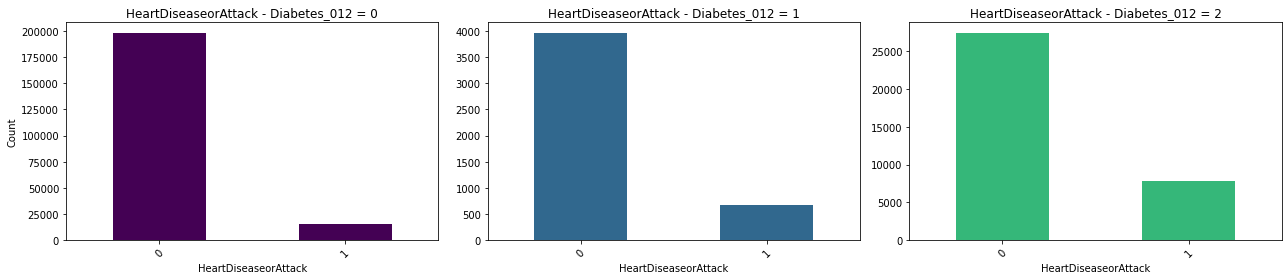

Total count for 'HeartDiseaseorAttack': 253680
Value counts for 'HeartDiseaseorAttack':
0.0    229787
1.0     23893
Name: HeartDiseaseorAttack, dtype: int64



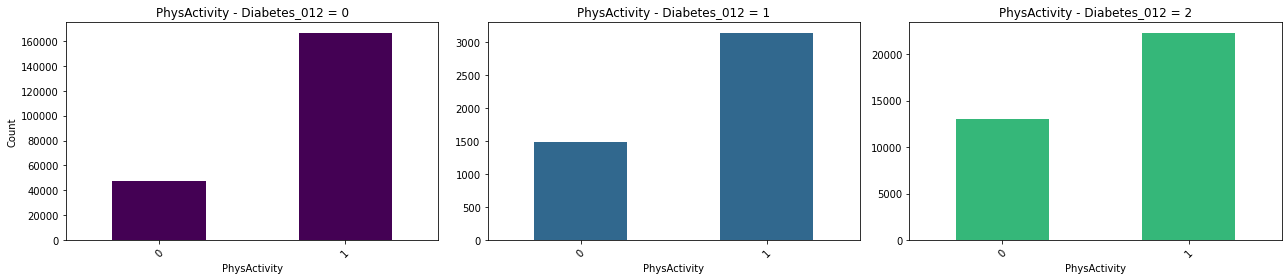

Total count for 'PhysActivity': 253680
Value counts for 'PhysActivity':
1.0    191920
0.0     61760
Name: PhysActivity, dtype: int64



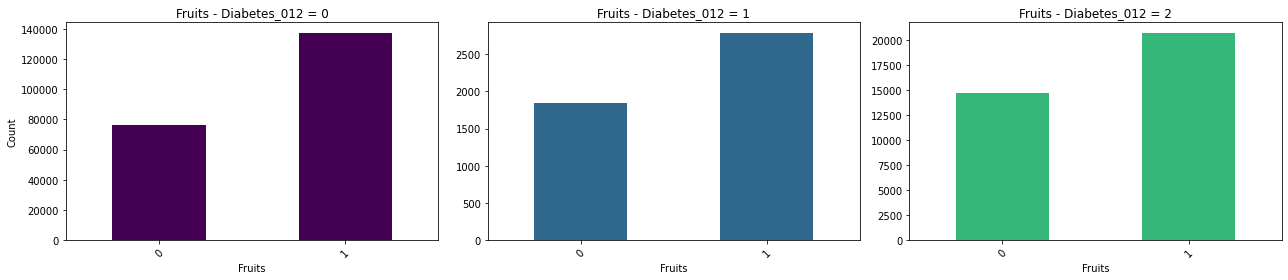

Total count for 'Fruits': 253680
Value counts for 'Fruits':
1.0    160898
0.0     92782
Name: Fruits, dtype: int64



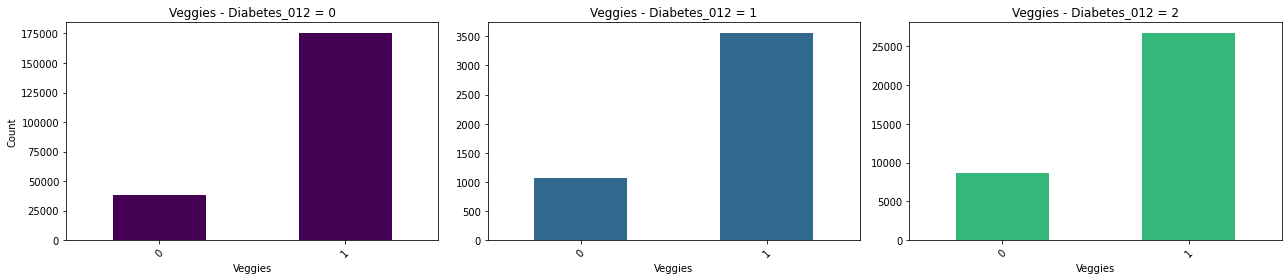

Total count for 'Veggies': 253680
Value counts for 'Veggies':
1.0    205841
0.0     47839
Name: Veggies, dtype: int64



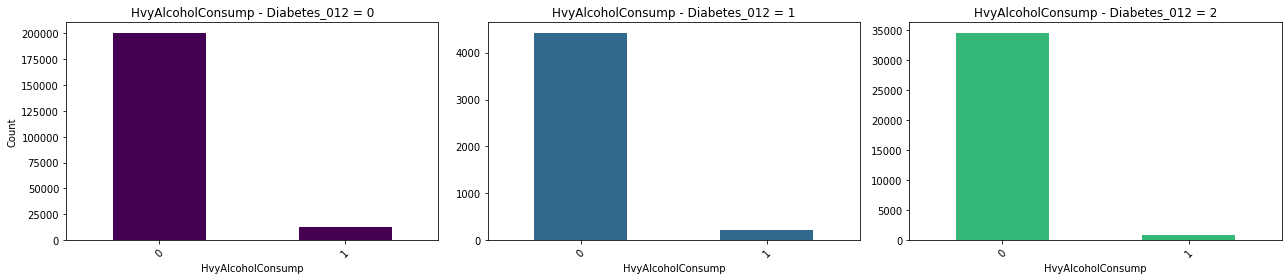

Total count for 'HvyAlcoholConsump': 253680
Value counts for 'HvyAlcoholConsump':
0.0    239424
1.0     14256
Name: HvyAlcoholConsump, dtype: int64



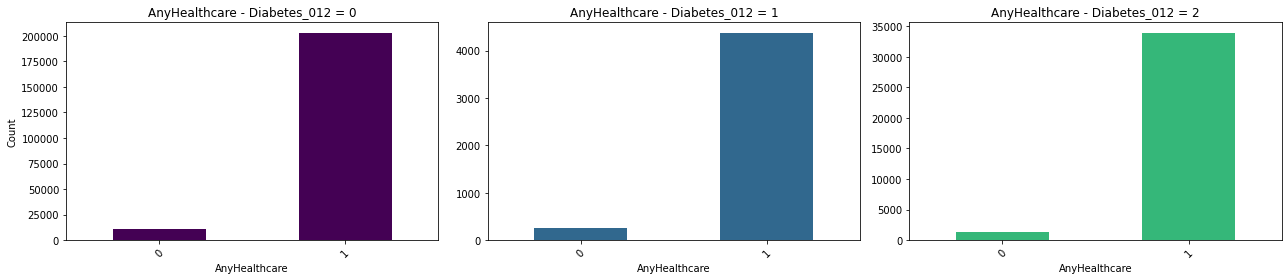

Total count for 'AnyHealthcare': 253680
Value counts for 'AnyHealthcare':
1.0    241263
0.0     12417
Name: AnyHealthcare, dtype: int64



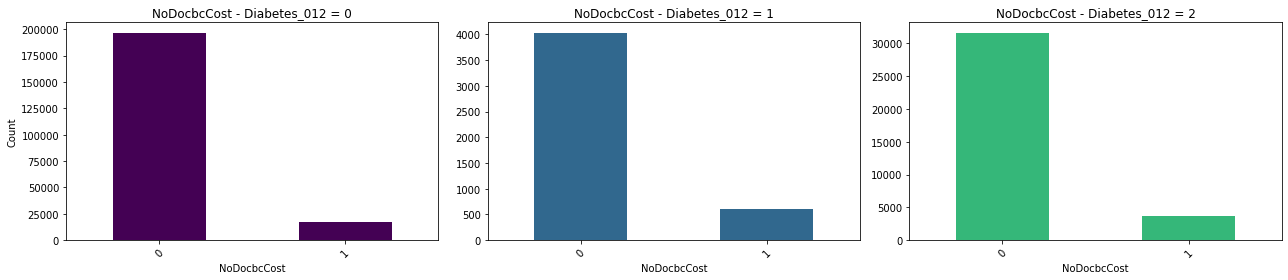

Total count for 'NoDocbcCost': 253680
Value counts for 'NoDocbcCost':
0.0    232326
1.0     21354
Name: NoDocbcCost, dtype: int64



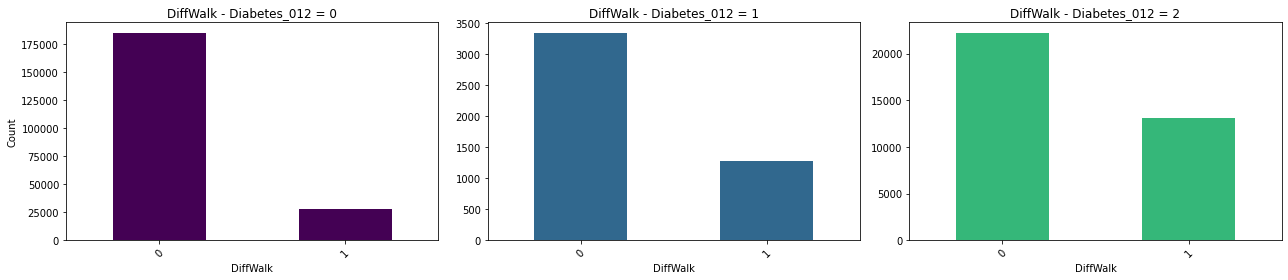

Total count for 'DiffWalk': 253680
Value counts for 'DiffWalk':
0.0    211005
1.0     42675
Name: DiffWalk, dtype: int64



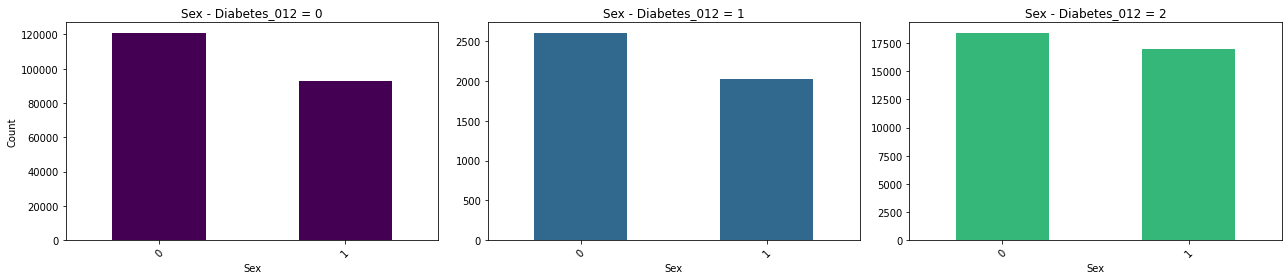

Total count for 'Sex': 253680
Value counts for 'Sex':
0.0    141974
1.0    111706
Name: Sex, dtype: int64



In [25]:
for idx, col in enumerate(Binary_cols):
    crosstab = dataset.groupby([col, 'Diabetes_012']).size().unstack(fill_value=0)
    categories = crosstab.columns
    fig, axes = plt.subplots(1, len(categories), figsize=(6 * len(categories), 4), sharey=False)
    for i, cat in enumerate(categories):
        ax = axes[i] if len(categories) > 1 else axes
        data = crosstab[cat]
        # Use log scale if the range is large, else linear
        if data.max() / max(data.min(), 1) > 100:
            data.plot(kind='bar', ax=ax, color=plt.cm.viridis(i / len(categories)), logy=True)
            ax.set_ylabel('Count (log scale)' if i == 0 else "")
        else:
            data.plot(kind='bar', ax=ax, color=plt.cm.viridis(i / len(categories)))
            ax.set_ylabel('Count' if i == 0 else "")
        ax.set_title(f"{col} - Diabetes_012 = {int(cat)}")
        ax.set_xlabel(col)
        ax.set_xticklabels(crosstab.index.astype(int), rotation=45)
    plt.tight_layout()
    plt.show()
    # Print total count for this binary column
    total_count = dataset[col].value_counts().sum()
    print(f"Total count for '{col}': {total_count}")
    # Print number of instances of each value of col
    print(f"Value counts for '{col}':\n{dataset[col].value_counts()}\n")
